In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import os

%matplotlib inline


file_path = '/net/pr2/projects/plgrid/plgglscclass/yelp-dataset/yelp_academic_dataset_business.json'

df = pd.read_json(file_path, lines=True)
df.head(3)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."


In [27]:
top_10_cities_names = df['city'].value_counts().head(10).index

city_stats = df[df['city'].isin(top_10_cities_names)].groupby('city').agg(
    Liczba_lokali=('business_id', 'count'),
    Srednia_ocena=('stars', 'mean'),
    Suma_recenzji=('review_count', 'sum'),
    Maks_recenzji_dla_jednego_lokalu=('review_count', 'max')
).sort_values(by='Liczba_lokali', ascending=False)

display(city_stats)

,Liczba_lokali,Srednia_ocena,Suma_recenzji,Maks_recenzji_dla_jednego_lokalu
city,,,,
Philadelphia,14569,3.623035,936240,5721
Tucson,9250,3.594919,387254,2126
Tampa,9050,3.583315,439506,3260
Indianapolis,7540,3.579708,349228,2233
Nashville,6971,3.637785,441053,6093
New Orleans,6209,3.822677,621361,7568
Reno,5935,3.761584,334610,3345
Edmonton,5054,3.439058,98204,486
Saint Louis,4827,3.594054,244360,3999


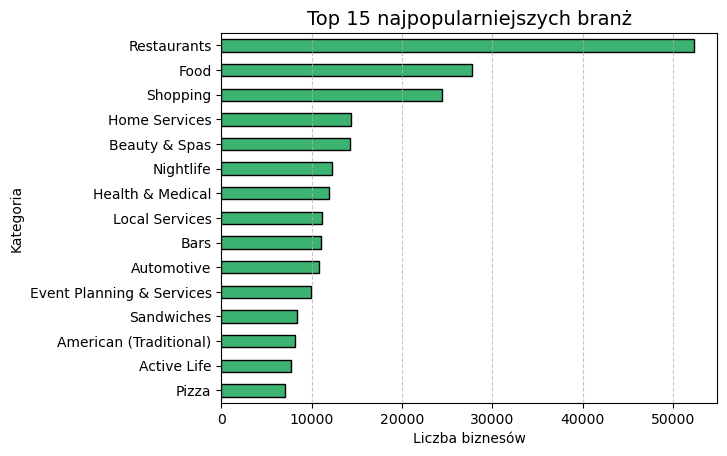

In [20]:
df_exploded = df.assign(categories=df['categories'].dropna().str.split(', ')).explode('categories')

# Zliczamy 15 najpopularniejszych
top_categories = df_exploded['categories'].value_counts().head(15)

# Wykres horyzontalny (barh) jest czytelniejszy dla długich nazw
top_categories.sort_values().plot(kind='barh', color='mediumseagreen', edgecolor='black')
plt.title('Top 15 najpopularniejszych branż', fontsize=14)
plt.xlabel('Liczba biznesów')
plt.ylabel('Kategoria')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

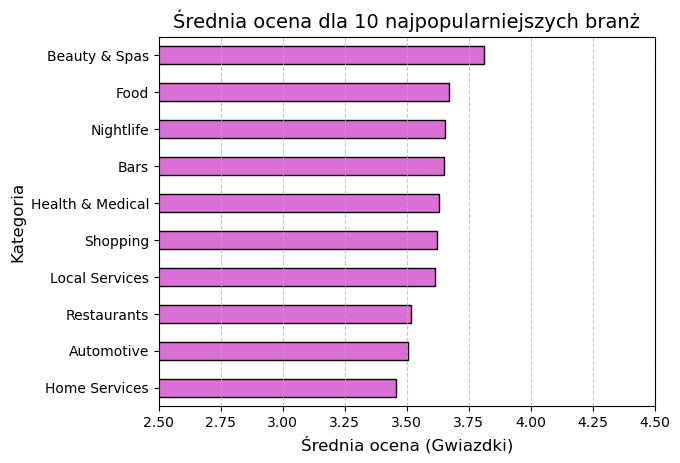

In [30]:
top_10_cats = df_exploded['categories'].value_counts().head(10).index

# Liczymy średnią gwiazdek dla tych 10 kategorii
avg_stars_top_cats = df_exploded[df_exploded['categories'].isin(top_10_cats)].groupby('categories')['stars'].mean().sort_values()

avg_stars_top_cats.plot(kind='barh', color='orchid', edgecolor='black')
plt.title('Średnia ocena dla 10 najpopularniejszych branż', fontsize=14)
plt.xlabel('Średnia ocena (Gwiazdki)', fontsize=12)
plt.ylabel('Kategoria', fontsize=12)
plt.xlim(2.5, 4.5) 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

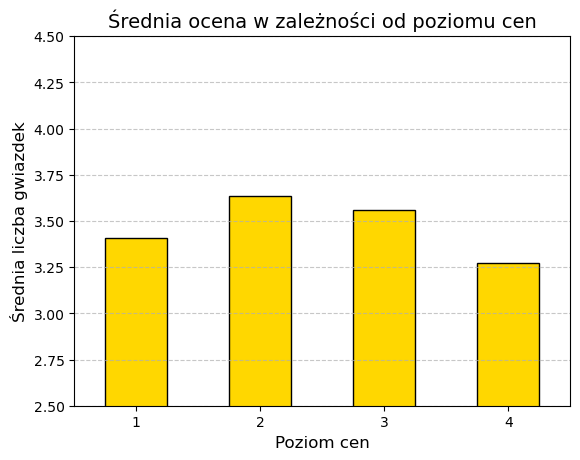

In [31]:
def get_price_range(attr_dict):
    if isinstance(attr_dict, dict):
        return attr_dict.get('RestaurantsPriceRange2')
    return None

# Tworzymy nową kolumnę
df['price_range'] = df['attributes'].apply(get_price_range)
df_price = df[df['price_range'].isin(['1', '2', '3', '4'])].copy()
# Liczymy średnią ocen dla poszczególnych poziomów
price_stars = df_price.groupby('price_range')['stars'].mean()

price_stars.plot(kind='bar', color='gold', edgecolor='black')
plt.title('Średnia ocena w zależności od poziomu cen', fontsize=14)
plt.xlabel('Poziom cen', fontsize=12)
plt.ylabel('Średnia liczba gwiazdek', fontsize=12)
plt.ylim(2.5, 4.5)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Used commands

srun -p plgrid-now --time 1:00:00 --pty /bin/bash -l

module load miniconda3

conda config --add envs_dirs ${SCRATCH}/.conda/envs

conda config --add pkgs_dirs ${SCRATCH}/.conda/pkgs

conda create -n yelp_env python=3.10 jupyter pandas matplotlib

conda activate yelp_env

jupyter notebook --no-browser --port=1053 --ip=ac0788
